# Análisis Exploratorio de Datos (EDA) — Dataset FDIC RIS

## Contexto institucional y descripción del dataset

La __Federal Deposit Insurance Corporation (FDIC)__ es una agencia independiente del gobierno de Estados Unidos creada por el Congreso para mantener la estabilidad y la confianza pública en el sistema financiero nacional. Entre sus funciones principales se encuentran asegurar depósitos bancarios, supervisar instituciones financieras, resolver entidades complejas en dificultades y gestionar procesos de receivership. 

Además de su función supervisora, la __FDIC__ actúa como una fuente de referencia para la investigación bancaria, publicando perfiles trimestrales, working papers y estadísticas bancarias estatales a través de su portal de datos públicos. Esto implica que no se trabaja con un dataset aislado sino con parte de un ecosistema oficial de datos regulatorios y de supervisión, lo que otorga solidez institucional a los análisis realizados.

### El sistema RIS — Research Information System

__RIS (Research Information System)__ es el entorno de datos integrado de la __FDIC__ para el estudio de instituciones financieras aseguradas. Según la documentación oficial, combina información demográfica, financiera, de fusiones, exámenes, holding companies, sucursales y otros campos relevantes para el análisis prudencial.

Sus características principales son:
- Cobertura histórica desde 1972 (__Call Reports__ del 31 de diciembre)
- Organización de datos trimestral, cada carpeta representa una fotografía del sistema bancario en un momento concreto
- Aproximadamente 2.800 variables por institución asegurada y más de 7.500 agregados sectoriales precalculados
- Diseñado específicamente para análisis longitudinales y comparativos del sector bancario

En este trabajo se utilizan los cortes trimestrales del periodo __2016Q1–2025Q4__ (40 trimestres), que corresponden a la etapa post-crisis financiera global, caracterizada por una relativa estabilidad del sistema bancario americano y un proceso progresivo de consolidación sectorial.

### Bases de datos RIS 

El diccionario oficial de __RIS__ distingue varias bases con funciones distintas dentro del sistema. La clave es que no son tablas equivalentes — cada una describe una dimensión distinta de la institución:

> __Structure Information (STRU)__: Contiene datos no financieros sobre la institución, como localización, agencia reguladora, charter y otros atributos estructurales . Esta base se deriva de fuentes como INST, BRANCH, CALL, CALLSL y MERGER, y es la más natural para definir el “perfil” de la entidad en un grafo o como metadatos de nodo.

>__Financial Time Series (FTS)__: Contiene los datos financieros fuente por trimestre . Se deriva de CALL, CALLSL, RIS-STRU y RIS-MERGER, por lo que funciona como el bloque financiero más cercano al dato original y temporal.

>__Complex Derived Integers (CDI)__: Contiene datos financieros enteros derivados matemáticamente a partir de RIS-STRU, RIS-MERGER y RIS-FTS . Esto suele incluir transformaciones, agregaciones o variables derivadas que facilitan ciertos cálculos o representaciones contables. 

>__Ratios (RAT)__: Reúne ratios financieros derivados de RIS-STRU, RIS-MERGER, RIS-FTS y RIS-CDI . Esta base es especialmente valiosa porque traduce magnitudes contables en indicadores interpretables para solvencia, liquidez, rentabilidad, capitalización o calidad de activos.

>__Merger (MERG)__: Contiene datos no financieros sobre fusiones, derivados de INST y otras fuentes externas . Su utilidad principal es capturar cambios estructurales, adquisiciones, absorciones o transiciones que pueden romper series y afectar la interpretación de un banco a lo largo del tiempo.

La arquitectura de datos es coherente con el diseño de __RIS__: __STRU__ define la entidad, __FTS__ aporta la serie temporal financiera, __CDI__ y __RAT__ añaden derivaciones útiles. __MERG__ captura eventos de reestructuración entre entidades. Todos estos datos ya son datos tabulares.

### La base Failures — variable objetivo del sistema

La base de __failures__ registra entidades que han fracasado, sido intervenidas o cerradas por la __FDIC__. A diferencia del resto de bases, no es una tabla de features financieras sino una _tabla de eventos_: recoge, como mínimo, el nombre de la entidad, su ubicación, la fecha de cierre y la institución adquirente cuando existe.

En este trabajo, failures cumple un doble rol:

1. __Label supervisado__: se usa para construir el problema de predicción: identificar qué instituciones terminan en quiebra dentro de una ventana temporal de 4 trimestres (horizonte estándar en literatura de _early warning systems_ bancarios).

2. __Criterio de selección de variables__: mediante correlación _punto-biserial_, se calcula el poder discriminativo de cada variable financiera respecto al evento de quiebra, permitiendo una selección estadísticamente justificable.

Por este motivo, __failures__ no se mezcla con __FTS__, __CDI__ o __RAT__ como si fuera otra fuente de covariables, sino que actúa como referencia supervisada para etiquetar la muestra y validar la selección de features.

## Objetivo del EDA

Este notebook tiene como objetivo explorar la estructura, calidad y características del dataset __RIS__ antes de cualquier transformación. Específicamente:

1. Verificar que la carga de datos desde el sistema de archivos es correcta
2. Analizar la estructura de cada base de datos en un trimestre piloto
3. Estudiar la evolución del número de entidades a lo largo del periodo
4. Explorar la tasa de valores ausentes por base de datos
5. Visualizar la distribución de variables financieras clave
6. Analizar la base failures y su cobertura en el periodo de estudio
7. Construir los cinco paneles completos como base para la siguiente fase 

Cargamos las dependencias necesarias y verificamos que la conexión con el sistema de archivos externo (`D:`) es correcta. La ruta al contenedor de datos se define en el archivo `.env` del proyecto y 
se carga mediante `python-dotenv`. El módulo `loader.py` abstrae la lógica de carga de cada tipo de archivo.

In [12]:
from pathlib import Path
from dotenv import load_dotenv
import sys
import numpy as np
import pandas as pd

# 1. Cargar .env desde la raíz del proyecto
project_root = Path.cwd().parents[0]
load_dotenv(project_root / ".env")

# 2. Añadir raíz del proyecto al sys.path
sys.path.insert(0, str(project_root))

# 3. Importar loader que importa de config.py correctamente las rutas
from src.data.loader import get_quarters, load_quarter, load_failures

# 4. Probar carga de los primeros trimestes
quarters = get_quarters()
print(f"Trimestres: {len(quarters)}")


file_types = ['FTS', 'CDI', 'RAT', 'MERG', 'STRU']
for dt in file_types:
    df = load_quarter(quarters[0], dt)
    print(f'Dimension de {dt} del trimestre 2016Q1 :{df.shape}')



Trimestres: 40
Dimension de FTS del trimestre 2016Q1 :(6193, 3369)
Dimension de CDI del trimestre 2016Q1 :(6193, 1097)
Dimension de RAT del trimestre 2016Q1 :(6193, 253)
Dimension de MERG del trimestre 2016Q1 :(26336, 61)
Dimension de STRU del trimestre 2016Q1 :(6546, 122)


Ahora veamos cuantas instancias tienen cada una de las bases de datos, es decir, cuantas filas totales contienen cada una de las bases de datos en el intervalo de tiempo de 2016-2025 y si contienen filas nulas.

In [13]:
# El número total de filas de todos los trimestres por Base de datos  (FTS, RAT, CDI....)

def total_rows(file_type):
    total = 0
    for q in get_quarters():
        try:
            df = load_quarter(q, file_type)
            total += len(df)
        except FileNotFoundError:
            pass
    return total

totals = {ft: total_rows(ft) for ft in file_types}

# Comprobamos que ninguna base de datos tiene alguna fila vacia
def validate_files():
    quarters = get_quarters()
    missing = []

    for q in quarters:
        suffix = q.name[3:]
        for ft in file_types:
            expected = q / f"{ft}{suffix}.csv"
            if not expected.exists():
                missing.append(str(expected))

    return missing

missing_files = validate_files()
print(totals, missing_files)

{'FTS': 206129, 'CDI': 206129, 'RAT': 206129, 'MERG': 1100520, 'STRU': 219576} []


Inspeccionamos la estructura de los 40 trimestres disponibles (`2016Q1–2025Q4`). Antes de procesar el dataset completo estudiamos un único trimestre (`ris1603`) para entender la forma y distribución de las variables. Todos los trimestres comparten la misma estructura de columnas, lo unico que cambian entre trimestres es el numero de instancias y de entidades.

Analizamos el número de columnas por base, los tipos de dato y la presencia de valores ausentes de media por columna, es decir qué porcentaje de valores faltan (`NaN`) en una columna de esa base en concreto en este corte inicial.

In [3]:
# Inspección del trimestre piloto
pilot_summary = {}

for ft in ['FTS', 'CDI', 'RAT', 'MERG', 'STRU']:
    df = load_quarter(quarters[0], ft)
    pilot_summary[ft] = {
        'filas': df.shape[0],
        'columnas': df.shape[1],
        'nan_medio_%': round(df.isnull().mean().mean() * 100, 1),
        'tipos': df.dtypes.value_counts().to_dict()
    }

print(f"{'Base':<8} {'Filas':>8} {'Columnas':>10} {'NaN medio %':>12}")
print("-" * 42)
for ft, info in pilot_summary.items():
    print(f"{ft:<8} {info['filas']:>8} {info['columnas']:>10} {info['nan_medio_%']:>11}%")

Base        Filas   Columnas  NaN medio %
------------------------------------------
FTS          6193       3369        27.3%
CDI          6193       1097        19.6%
RAT          6193        253        17.2%
MERG        26336         61        11.6%
STRU         6546        122         8.6%


Esto nos deja ciertas observaciónes: __FTS__, __CDI__ y __RAT__ tienen exactamente el mismo número de filas, es decir son la misma población de bancos vista desde tres ángulos distintos. __MERG__ tiene significativamente más filas ya que es un archivo acumulativo que crece con el historial de fusiones. Y __STRU__ tiene ligeramente más filas que __FTS/CDI/RAT__ porque  incluye entidades que ya no reportan financieramente pero siguen en el registro estructural.

Visualizamos la distribución de cuatro variables representativas (ratios financieros) de __RAT__ en el trimestre piloto. __RAT__ contiene ratios ya normalizados e interpretables directamente representativos de
- _Rentabilidad_ (`ROA`), mide el beneficio neto sobre activos medios, así que captura la capacidad de generar ganancias con los recursos del banco.
- _Margen financiero_ (`NIMY`), es el margen de interés neto sobre activos de generación de intereses, por lo que refleja el negocio bancario básico de captar y prestar
- _Calidad de cartera_ (`NTLNLSR `), medición de _net charge-offs / loans_, captura pérdidas netas sobre la cartera de préstamos, que es una señal directa de deterioro crediticio.
- _Capitalización_ (`EQV`), _Equity capital / total assets_ indica cuánto colchón de capital tiene el banco frente a sus activos, es decir, su solvencia o capitalización.
 
 La distribución asimétrica es esperable en datos bancarios: la mayoría de bancos son pequeños y conservadores, con unos pocos grandes que son _outliers_.

__NOTA:__ Un detalle importante es que los valores numéricos en los `CSV` originales de la __FDIC__ usan comas como separador de miles (e.g. `67,877,350`), lo que `Pandas 3.0.3` interpreta como `string`.

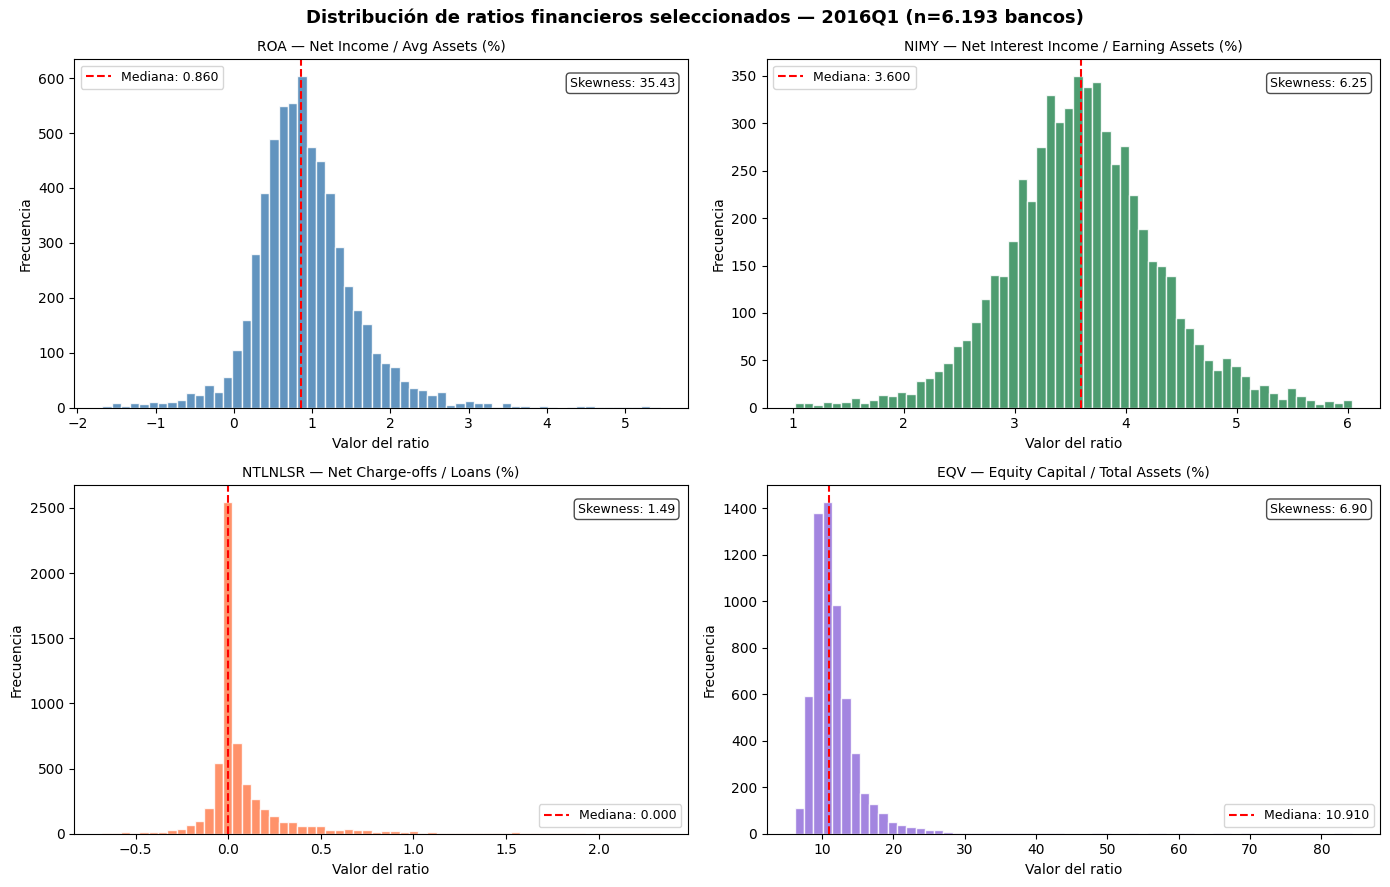


Variable            N      Media    Mediana        Std   Skewness
-------------------------------------------------------
ROA              6176      1.075      0.860      3.686      35.43
NIMY             6167      3.639      3.600      1.074       6.25
NTLNLSR          6081      0.113      0.000      0.750       1.49
EQV              6176     12.681     10.910      9.710       6.90


In [4]:
import matplotlib.pyplot as plt
import os

os.makedirs(project_root / 'notebooks' / 'figures', exist_ok=True)

rat_pilot = load_quarter(quarters[0], 'RAT')

# Limpiar tipos
for col in ['ROA', 'NIMY', 'NTLNLSR', 'EQV']:
    rat_pilot[col] = pd.to_numeric(
        rat_pilot[col].astype(str).str.replace(',', '', regex=False),
        errors='coerce'
    )

variables = [
    ('ROA',     'ROA — Net Income / Avg Assets (%)',               'steelblue',    ''),
    ('NIMY',    'NIMY — Net Interest Income / Earning Assets (%)',  'seagreen',     ''),
    ('NTLNLSR', 'NTLNLSR — Net Charge-offs / Loans (%)',           'coral',        ''),
    ('EQV',     'EQV — Equity Capital / Total Assets (%)',          'mediumpurple', ''),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Distribución de ratios financieros seleccionados — 2016Q1 (n=6.193 bancos)',
             fontsize=13, fontweight='bold')

for ax, (col, title, color, _) in zip(axes.flatten(), variables):
    data = rat_pilot[col].dropna()
    skewness = data.skew()
    # Eliminar outliers extremos para visualización
    q1, q99 = data.quantile(0.01), data.quantile(0.99)
    data_trim = data[(data >= q1) & (data <= q99)]
    ax.hist(data_trim, bins=60, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(data.median(), color='red', linestyle='--',
               linewidth=1.5, label=f'Mediana: {data.median():.3f}')
    ax.set_title(f'{title}', fontsize=10)
    ax.set_xlabel('Valor del ratio')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=9)
    # Skewness en esquina superior
    ax.text(0.98, 0.95, f'Skewness: {skewness:.2f}',
            transform=ax.transAxes, fontsize=9,
            ha='right', va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.savefig(project_root / 'notebooks' / 'figures' / 'eda_distributions_pilot.png', dpi=150)
plt.show()

# Resumen estadístico
print(f"\n{'Variable':<12} {'N':>8} {'Media':>10} {'Mediana':>10} {'Std':>10} {'Skewness':>10}")
print("-" * 55)
for col, title, _, _ in variables:
    data = rat_pilot[col].dropna()
    print(f"{col:<12} {len(data):>8} {data.mean():>10.3f} {data.median():>10.3f} "
          f"{data.std():>10.3f} {data.skew():>10.2f}")

Veamos ahora la evolución del número de bancos activos en todo nuestro periodo de actuación (`2016–2025`). El sistema bancario americano ha experimentado una consolidación sostenida desde la crisis financiera de 2008 (fusiones, adquisiciones y cierres) reducen el número de bancos activos cada trimestre. Esta tendencia tiene implicaciones directas para el pipeline de datos que crearemos, el _panel temporal_ es un panel no balanceado donde no todos los bancos aparecen en todos los periodos.

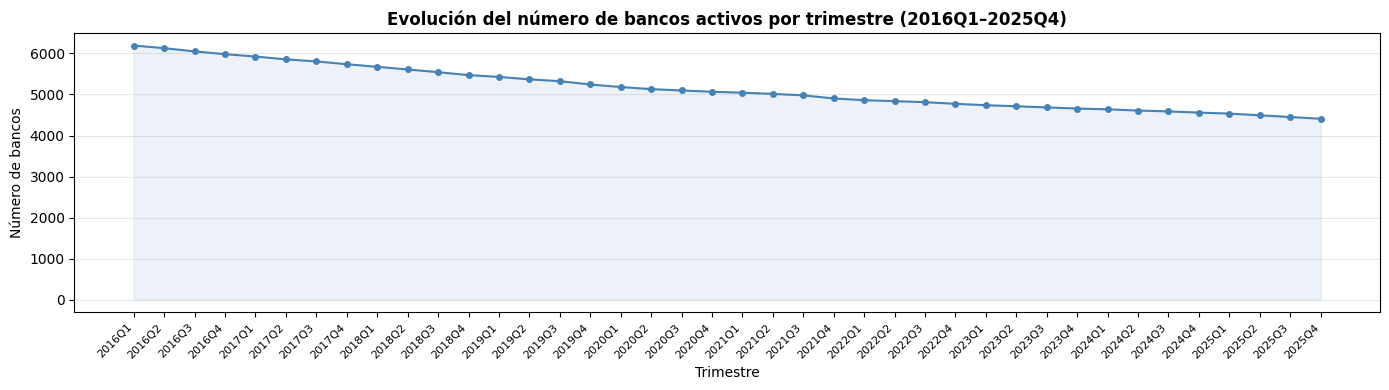

Bancos en 2016Q1: 6193
Bancos en 2025Q4: 4408
Reducción total: 1785 bancos (28.8%) en 10 años


In [5]:
bank_counts = []
quarter_map_str = {'03': 'Q1', '06': 'Q2', '09': 'Q3', '12': 'Q4'}
for q in quarters:
    suffix = q.name[3:]
    year = '20' + suffix[:2]
    period = year + quarter_map_str[suffix[2:]]
    df = load_quarter(q, 'FTS')
    bank_counts.append({'period': period, 'n_banks': len(df)})

df_counts = pd.DataFrame(bank_counts)

plt.figure(figsize=(14, 4))
plt.plot(df_counts['period'], df_counts['n_banks'],
         marker='o', markersize=4, color='steelblue', linewidth=1.5)
plt.fill_between(range(len(df_counts)), df_counts['n_banks'],
                 alpha=0.1, color='steelblue')
plt.xticks(range(len(df_counts)), df_counts['period'],
           rotation=45, ha='right', fontsize=8)
plt.title('Evolución del número de bancos activos por trimestre (2016Q1–2025Q4)',
          fontweight='bold')
plt.xlabel('Trimestre')
plt.ylabel('Número de bancos')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(project_root / 'notebooks' / 'figures' / 'eda_bank_evolution.png', dpi=150)
plt.show()

reduccion = df_counts.iloc[0]['n_banks'] - df_counts.iloc[-1]['n_banks']
pct = reduccion / df_counts.iloc[0]['n_banks'] * 100
print(f"Bancos en 2016Q1: {df_counts.iloc[0]['n_banks']}")
print(f"Bancos en 2025Q4: {df_counts.iloc[-1]['n_banks']}")
print(f"Reducción total: {reduccion} bancos ({pct:.1f}%) en 10 años")

A parte de las cinco bases de __RIS__ tenemos la base __failures__ la cual como ya hemos visto contiene el registro oficial de la __FDIC__ de instituciones cerradas o resueltas. Es una tabla de eventos, no de features financieras, ya que cada fila representa un banco que ha dejado de operar con su fecha de cierre y tipo de resolución.

En nuestro periodo de análisis (2016–2025) el número de quiebras es muy reducido, lo que refleja la estabilidad del sistema bancario post-crisis. Este dato es fundamental: el desbalanceo extremo de clases condiciona el diseño del pipeline supervisado y la elección de métricas de evaluación.

In [6]:
failures = load_failures()
failures['FAILDATE'] = pd.to_datetime(failures['FAILDATE'], format='%m/%d/%Y')
failures['CERT'] = failures['CERT'].astype(str)

print(f"Total bancos en el registro de failures FDIC: {len(failures)}")
print(f"Periodo cubierto: {failures['FAILDATE'].min().year} — {failures['FAILDATE'].max().year}")
print(f"\nTipos de resolución:")
print(failures['RESTYPE'].value_counts())
print(f"\nBancos fallidos en nuestro periodo (2016-2025): {len(failures[failures['FAILYR'] >= 2016])}")
print(f"\nDetalle por año:")
print(failures[failures['FAILYR'] >= 2016][['CERT','NAME','FAILDATE','RESTYPE']]
      .sort_values('FAILDATE').to_string(index=False))

Total bancos en el registro de failures FDIC: 561
Periodo cubierto: 2007 — 2025

Tipos de resolución:
RESTYPE
FAILURE       548
ASSISTANCE     13
Name: count, dtype: int64

Bancos fallidos en nuestro periodo (2016-2025): 30

Detalle por año:
 CERT                                            NAME   FAILDATE RESTYPE
20364                      NORTH MILWAUKEE STATE BANK 2016-03-11 FAILURE
 9956                              TRUST COMPANY BANK 2016-04-29 FAILURE
35312                          FIRST CORNERSTONE BANK 2016-05-06 FAILURE
11297                    THE WOODBURY BANKING COMPANY 2016-08-19 FAILURE
   91                                     ALLIED BANK 2016-09-23 FAILURE
34951                          HARVEST COMMUNITY BANK 2017-01-13 FAILURE
19328                   SEAWAY BANK AND TRUST COMPANY 2017-01-27 FAILURE
35495                                   PROFICIO BANK 2017-03-03 FAILURE
58302                                  FIRST NBC BANK 2017-04-28 FAILURE
30003                       

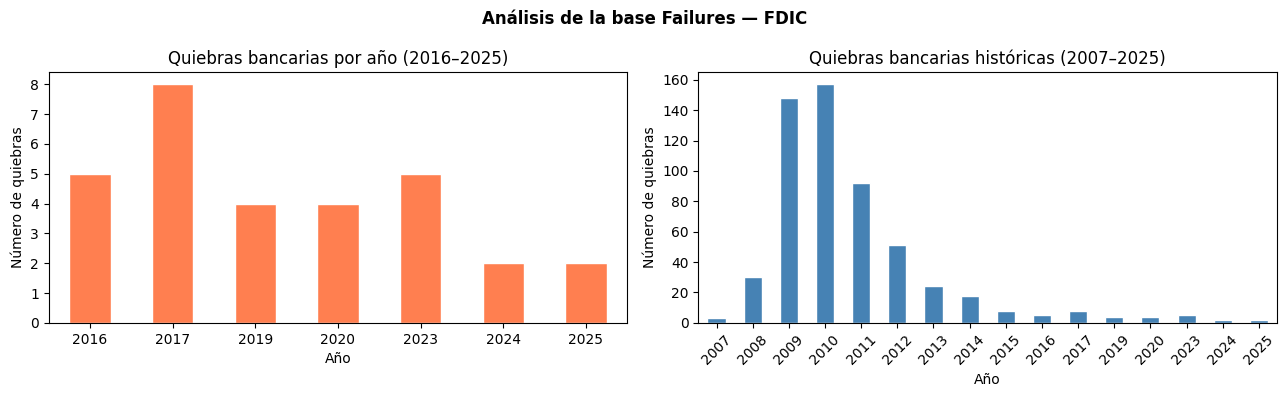

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Análisis de la base Failures — FDIC', fontweight='bold')

# Fallos por año en nuestro periodo
failures[failures['FAILYR'] >= 2016]['FAILYR'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='coral', edgecolor='white'
)
axes[0].set_title('Quiebras bancarias por año (2016–2025)')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Número de quiebras')
axes[0].tick_params(axis='x', rotation=0)

# Distribución histórica completa
failures['FAILYR'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='steelblue', edgecolor='white'
)
axes[1].set_title('Quiebras bancarias históricas (2007–2025)')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Número de quiebras')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(project_root / 'notebooks' / 'figures' / 'eda_failures.png', dpi=150)
plt.show()

## Exploración de valores ausentes

En el dataset RIS los valores ausentes son en su mayoría _estructurales_, no aleatorios. Un banco pequeño no reporta variables de derivados financieros complejos simplemente porque no opera con ellos. Esta distinción es importante para interpretar correctamente los `NaN` ya que no indican necesariamente calidad deficiente del dato sino inaplicabilidad de la variable a ese tipo de entidad.

Exploramos la distribución de `NaN` por base de datos para entender su magnitud y patrón antes de tomar decisiones de limpieza en la siguiente fase.

In [ ]:
# NaN por base de datos sobre el panel tabular completo
from src.utils.config import PROCESSED_DIR

nan_summary = {}
for name in ['FTS', 'CDI', 'RAT', 'MERG', 'STRU']:
    df = pd.read_parquet(PROCESSED_DIR / f"panel_{name}.parquet")
    nan_rates = df.isnull().mean()
    nan_summary[name] = {
        'total_cols': df.shape[1],
        'cols_sin_nan': (nan_rates == 0).sum(),
        'cols_nan_lt50': (nan_rates < 0.5).sum(),
        'cols_nan_gt50': (nan_rates >= 0.5).sum(),
        'nan_medio_%': round(nan_rates.mean() * 100, 1),
    }

print(f"{'Base':<8} {'Total cols':>12} {'Sin NaN':>10} {'NaN<50%':>10} {'NaN≥50%':>10} {'NaN medio':>12}")
print("-" * 65)
for name, info in nan_summary.items():
    print(f"{name:<8} {info['total_cols']:>12} {info['cols_sin_nan']:>10} "
          f"{info['cols_nan_lt50']:>10} {info['cols_nan_gt50']:>10} "
          f"{info['nan_medio_%']:>11}%")

Base       Total cols    Sin NaN    NaN<50%    NaN≥50%    NaN medio
-----------------------------------------------------------------
FTS              3370        173       1577       1793        45.2%
CDI              1098        123        757        341        28.4%
RAT               254          9        219         35        17.9%
MERG               62         16         60          2        11.2%
STRU              123         78        116          7         8.4%


Una vez explorada la estructura del dataset construimos los cinco paneles tabulares completos concatenando los 40 trimestres de cada base de datos. Cada panel añade una columna `period` en formato `YYYYQX` derivada del nombre de la carpeta trimestral.

Los paneles se guardan en formato `parquet`, ya que ocupan 3-4x menos memoria que `CSV` y carga mucho más rápido, en `D:/financial_risk_data/processed/` haciendo que cada panel tabular sera un archivo con el que trabajaremos mas adelante.
```p
processed/
    panel_FTS.parquet
    panel_CDI.parquet
    panel_RAT.parquet
    panel_MERG.parquet
    panel_STRU.parquet
``` 

In [ ]:
from src.utils.config import PROCESSED_DIR

print("PROCESSED_DIR:", PROCESSED_DIR)

def clean_dtypes(df: pd.DataFrame) -> pd.DataFrame: 
    """Limpia tipos mixtos y elimina separadores de miles."""
    for col in df.columns:
        if df[col].dtype == 'object' or str(df[col].dtype) == 'string':
            cleaned = df[col].astype(str).str.replace(',', '', regex=False)
            converted = pd.to_numeric(cleaned, errors='coerce')
            if converted.notna().sum() > len(df) * 0.1:
                df[col] = converted
            else:
                df[col] = df[col].astype(str).replace('nan', pd.NA)
    return df


def build_panel(file_type: str) -> pd.DataFrame:
    quarters = get_quarters()
    frames = []
    quarter_map = {'03': 'Q1', '06': 'Q2', '09': 'Q3', '12': 'Q4'}
    
    for q in quarters:
        try:
            df = load_quarter(q, file_type)
            suffix = q.name[3:]
            year = '20' + suffix[:2]
            df = df.copy()
            df['period'] = year + quarter_map[suffix[2:]]
            df = clean_dtypes(df)
            frames.append(df)
            print(f"  {q.name}: {df.shape}")
        except Exception as e:
            print(f"  Warning {q.name}: {e}")
    
    panel = pd.concat(frames, ignore_index=True)
    
    # Segunda pasada ligera — resolver conflictos de tipo entre trimestres
    for col in panel.columns:
        if str(panel[col].dtype) in ['object', 'string']:
            converted = pd.to_numeric(
                panel[col].astype(str).str.replace(',', '', regex=False), 
                errors='coerce'
            )
            if converted.notna().sum() > len(panel) * 0.05:
                panel[col] = converted
            else:
                # Forzar string puro para parquet
                panel[col] = panel[col].astype(str).where(
                    panel[col].notna(), other=None
                )
    
    print(f"\nPanel {file_type} total: {panel.shape}")
    return panel

# construimos los paneles y los guardamos
for file_type in ['FTS', 'CDI', 'RAT', 'MERG', 'STRU']:
    print(f"\n{'='*40}")
    print(f"Procesando {file_type}...")
    panel = build_panel(file_type)
    output_path = PROCESSED_DIR / f"panel_{file_type}.parquet"
    panel.to_parquet(output_path, index=False)
    print(f"Guardado: {output_path}")

#verificamos que se han creado en la carpeta correcta
for file_type in ['FTS', 'CDI', 'RAT', 'MERG', 'STRU']:
    df = pd.read_parquet(PROCESSED_DIR / f"panel_{file_type}.parquet")
    n_cert = df['CERT'].nunique() if 'CERT' in df.columns else 'N/A'
    print(f"{file_type}: {df.shape} | periods: {df['period'].nunique()} | CERT únicos: {n_cert}")

## Resumen del EDA

Los cinco paneles completos están disponibles en `D:/financial_risk_data/processed/`. El dataset __RIS__ presenta las siguientes características relevantes para el pipeline:

- __Panel de datos no balanceado__: el número de bancos decrece de 6193 en 2016Q1 a 4408 en 2025Q4 por consolidación sectorial.
- __Alta dimensionalidad__: 4902 columnas entre todas la bases de datos con las que operar
- __NaN estructurales__: las variables opcionales generan tasas de `NaN` elevadas en columnas específicas a ciertos tipos de institución
- __Desbalanceo extremo en failures__: 30 quiebras en 10 años sobre 6.000 bancos activos por trimestre
- __MERG acumulativo__: requiere tratamiento especial por duplicidad entre trimestres

Como vemos tenemos un conjunto de columnas intratable a simple vista, unas 4902 columnas repartidas en cinco bases de datos diferentes que componen el dataset de __RSI__, el cual se tendra que tratar para reducir la dimensionalidad, eliminar variables redundantes, que contengan demasiados valores `NaN`, etc... El análisis detallado de estas características y las decisiones metodológicas de selección de variables se desarrollan en `02_feature_engineering.ipynb`.

La idea principal es pensar en estos paneles como diferentes subdataset con los que crearemos los _tabular data panels_, que seran paneles tabulares, para la ingesta del modelo transformer de `TabPFN`, mediante la union de los paneles `FTS` + `CDI` + `RAT` y su transformación a un panel tabular temporal, y crear una vista estructural con `STRU`, la cual define los nodos y atributos del grafo temporal `T_GCN` o `EvolveGCN` y una vista de eventos con `MERG`, que genera aristas dinámicas y discontinuidades para el grafo.

__OBSERVACIÓN__: Para saber que son las etiquetas y a que hacen referencia podemos consultar esos datos en la propia base de datos de La __FDIC__, en la pagina de _RIS Dictionary_, el cual es un buscador que proporciona información sobre las columnas (features/caracteristicas) de cada base de datos, como estan definidas y a que base pertenecen (a una o más bases de datso). El __RIS__ no es un solo dataset, sino una familia de bases con funciones distintas dentro del mismo sistema.

